In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, kruskal, mannwhitneyu
from scipy.stats import f_oneway
from itertools import combinations
import seaborn as sns
from factor_analyzer import FactorAnalyzer
import glob
import pingouin as pg
from scipy.stats import ttest_ind 


# Important functions

In [90]:
def analyze_groups_anova(df, score_col, group_col):
    # Extract data for each group
    groups = df[group_col].unique()
    group_data = [df[df[group_col] == group][score_col].dropna() for group in groups]
    
    # Combine all groups into one dataset
    all_data = pd.concat(group_data)
    grand_mean = all_data.mean()

    # Calculate Sum of Squares Between (SS_between)
    SS_between = sum(len(group) * (group.mean() - grand_mean)**2 for group in group_data)

    # Calculate Sum of Squares Within (SS_within)
    SS_within = sum(sum((group - group.mean())**2) for group in group_data)

    # Calculate Total Sum of Squares (SS_total)
    SS_total = SS_between + SS_within

    # Calculate Eta Squared (η²)
    eta_squared = SS_between / SS_total

    # Perform one-way ANOVA
    stat, p = f_oneway(*group_data)

    # Print results
    print("SS stands for Sum of Squares")
    print(f"SS_between: {SS_between:.4f}")
    print(f"SS_within: {SS_within:.4f}")
    print(f"SS_total: {SS_total:.4f}")
    print(f"Effect Size (Eta Squared, η²): {eta_squared:.4f}")
    print(f"ANOVA Results: F-statistic = {stat:.4f}, p-value = {p:.4f}")
    if p < 0.05:
        print("There is a significant difference between the groups.")
    else:
        print("No significant difference between the groups.")

    # Plot the scores for each group
    plt.figure(figsize=(8, 6))
    boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)
    plt.title(f"{score_col} by {group_col}")

    # Assign different colors to each group
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    for box, color in zip(boxplot['boxes'], colors):
        box.set_facecolor(color)

    plt.ylabel(score_col)
    plt.xlabel(group_col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Return results as a dictionary
    return {
        "SS_between": SS_between,
        "SS_within": SS_within,
        "SS_total": SS_total,
        "eta_squared": eta_squared,
        "anova_stat": stat,
        "anova_p_value": p
    }

In [91]:
def analyze_kruskal_test(df, score_col, group_col):
    groups = df[group_col].unique()
    group_data = [df[df[group_col] == group][score_col].dropna() for group in groups]
    stat, p = kruskal(*group_data)
    print(f"Kruskal-Wallis test statistic = {stat:.4f}, p-value = {p:.4f}")
    if p < 0.05:
        print("There is a significant difference between the groups.")
    else:
        print("No significant difference between the groups.")
    plt.figure(figsize=(8, 6))
    boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)
    plt.title(f"{score_col} by {group_col} (Kruskal-Wallis Test)")
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    for box, color in zip(boxplot['boxes'], colors):
        box.set_facecolor(color)

    plt.ylabel(score_col)
    plt.xlabel(group_col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Return results as a dictionary
    return {
        "kruskal_stat": stat,
        "kruskal_p_value": p
    }

In [92]:
def calculate_omega(data):
    fa = FactorAnalyzer(n_factors=1, rotation=None)
    fa.fit(data)
    loadings = fa.loadings_[:, 0]
    uniquenesses = fa.get_uniquenesses()
    numerator = np.sum(loadings)**2
    denominator = numerator + np.sum(uniquenesses)
    return numerator / denominator

In [93]:
# score meaning is (Source: Steiner, 2003, p102)
def interpret_omega(score):
    if score > 0.9:
        return "Excellent"
    elif 0.7 <= score <= 0.9:
        return "Good"
    elif 0.6 <= score < 0.7:
        return "Acceptable"
    elif 0.5 <= score < 0.6:
        return "Poor"
    else:
        return "Unacceptable"

In [94]:
def testing_for_assumptions_by_group(df, score_col="IEQ Score", group_col="Group"):
    print(f"# Testing assumptions for {score_col} #\n")

    groups = df[group_col].unique()
    group_data = {g: df[df[group_col] == g][score_col].dropna() for g in groups}

    # 1. Shapiro–Wilk Test for Normality
    print("## Shapiro–Wilk Test for Normality ##")
    normality = {}
    for group, data in group_data.items():
        print(f"Group {group}:")
        if len(data) < 3:
            print(f"  ⚠️ Not enough data (n={len(data)}) to test normality.\n")
            normality[group] = False
            continue
        stat, p = shapiro(data)
        normal = p > 0.05
        normality[group] = normal
        if normal:
            print(f"  ✔️ Stat = {stat:.4f}, p = {p:.4f} → Data appears normal\n")
        else:
            print(f"  ❌ Stat = {stat:.4f}, p = {p:.4f} → Data not normal\n")

    print("## Levene’s Test for Equal Variances ##")
    data_lists = [d for d in group_data.values() if len(d) >= 2]
    if len(data_lists) >= 2:
        stat, p = levene(*data_lists)
        equal_var = p > 0.05
        if equal_var:
            print(f"  ✔️ Stat = {stat:.4f}, p = {p:.4f} → Variances are equal\n")
        else:
            print(f"  ❌ Stat = {stat:.4f}, p = {p:.4f} → Variances are not equal\n")
    else:
        equal_var = False
        print("  ⚠️ Not enough groups with sufficient data to test variance\n")

    print(f"# Final Group Comparison Test for {score_col} #")
    normal_all = all(normality.values())
    sufficient_groups = len([group_data[g] for g in groups if len(group_data[g]) >= 2]) > 2
    if normal_all and equal_var:
        print("✅ All assumptions met. Running ANOVA:")
        if(sufficient_groups):
            stat, p = f_oneway(*[group_data[g] for g in groups if len(group_data[g]) >= 2])
            print(f"  ✔️ ANOVA Stat = {stat:.4f}, p = {p:.4f}")
        return 1
    else:
        print("❌ Assumptions not met. Using non-parametric Kruskal–Wallis:")
        if(sufficient_groups):
            stat, p = kruskal(*[group_data[g] for g in groups if len(group_data[g]) >= 2])
            print(f"  ✔️ Kruskal–Wallis Stat = {stat:.4f}, p = {p:.4f}")
        return 0


# Pre-Questionnaire Data Processingprocessing

Load the xlsx file

In [98]:
pre_path = glob.glob("Qustionare_data\\Pre\\*.xlsx")[0]
print(pre_path)
df = pd.read_excel(pre_path, sheet_name=0)
columns_to_plot = [
    "What is your age?",
    "Do you use glasses?",
    "VR",
    "Bartending",
    "Are you currently under the effect of anything that can enhance motion sickness or affect your heart rate?"
]
df 

Qustionare_data\Pre\MED 802 Test survey (Part 1)(1-26).xlsx


,ID,Starttidspunkt,Færdiggørelsestidspunkt,Mail,Navn,Senest ændret tidspunkt,Do you consent?,What is your age?,Do you use glasses?,VR,Bartending,Are you currently under the effect of anything that can enhance motion sickness or affect your heart rate?,Your test Number (Get your test conductor to fill this out)
0,4,2025-05-05 11:33:00,2025-05-05 11:33:12,anonymous,NaN,NaN,Yes,25-34,No,A lot,None,Minor heart condition;,1
1,5,2025-05-05 11:55:57,2025-05-05 12:05:58,anonymous,NaN,NaN,Yes,25-34,Yes,Medium,Quite a bit,Caffeine;,2
2,6,2025-05-05 14:01:59,2025-05-05 14:04:33,anonymous,NaN,NaN,Yes,25-34,No,Medium,Medium,Matcha;,3
3,7,2025-05-05 14:35:11,2025-05-05 14:36:29,anonymous,NaN,NaN,Yes,18-24,No,A little,None,None;,4
4,8,2025-05-05 14:56:05,2025-05-05 14:57:19,anonymous,NaN,NaN,Yes,25-34,No,Quite a bit,A little,Caffeine;,5
5,9,2025-05-06 09:06:37,2025-05-06 09:35:53,anonymous,NaN,NaN,Yes,18-24,I'm using lenses right now,A little,None,None;,6
6,10,2025-05-06 09:37:24,2025-05-06 10:03:18,anonymous,NaN,NaN,Yes,18-24,No,A little,Medium,Caffeine;,7
7,11,2025-05-06 10:03:21,2025-05-06 10:31:30,anonymous,NaN,NaN,Yes,18-24,Yes,A little,None,Caffeine;,8
8,12,2025-05-06 10:32:24,2025-05-06 11:02:29,anonymous,NaN,NaN,Yes,18-24,Yes,A little,None,None;,9
9,13,2025-05-06 12:34:07,2025-05-06 12:34:12,anonymous,NaN,NaN,Yes,18-24,Yes,None,Medium,Caffeine;,10


In [96]:
# Initialize an empty DataFrame to store the results
answer_counts_df = pd.DataFrame()

for column in columns_to_plot:
    # Extract data from each column, count unique answers, and add to the new DataFrame
    answer_counts = df[column].value_counts().reset_index()
    answer_counts.columns = [column, "Count"]
    answer_counts_df = pd.concat([answer_counts_df, answer_counts], axis=1)

# Calculate z-scores for each column with numerical data
z_scores = answer_counts_df.select_dtypes(include=['float64', 'int64']).apply(stats.zscore)

answer_counts_df['Outlier'] = (z_scores.abs() > 3).any(axis=1)

answer_counts_df

,What is your age?,Count,Do you use glasses?,Count,VR,Count,Bartending,Count,Are you currently under the effect of anything that can enhance motion sickness or affect your heart rate?,Count,Outlier
0,18-24,16.0,No,16.0,A little,8.0,None,13.0,None;,15,False
1,25-34,10.0,Yes,9.0,Quite a bit,7.0,Medium,6.0,Caffeine;,7,False
2,NaN,NaN,I'm using lenses right now,1.0,Medium,5.0,Quite a bit,4.0,Minor heart condition;,1,False
3,NaN,NaN,NaN,NaN,A lot,3.0,A little,3.0,Matcha;,1,False
4,NaN,NaN,NaN,NaN,None,3.0,NaN,NaN,Medicine ;,1,False
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A wittle bit sick;,1,False


C:\Users\Christian\AppData\Local\Temp\ipykernel_17060\750008034.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="VR", palette="viridis")


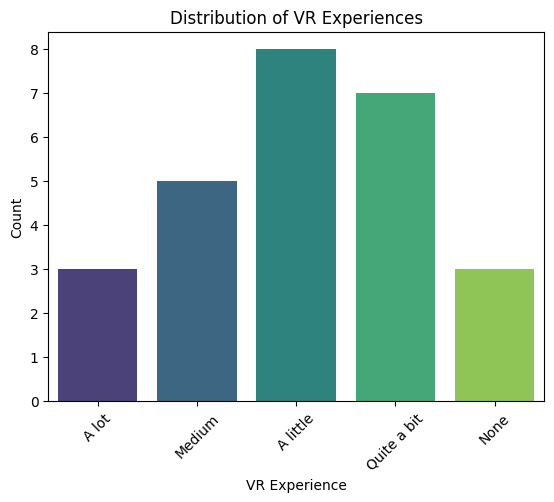

In [99]:
sns.countplot(data=df, x="VR", palette="viridis")
plt.title("Distribution of VR Experiences")
plt.xlabel("VR Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

C:\Users\Christian\AppData\Local\Temp\ipykernel_17060\4198566627.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Bartending", palette="viridis")


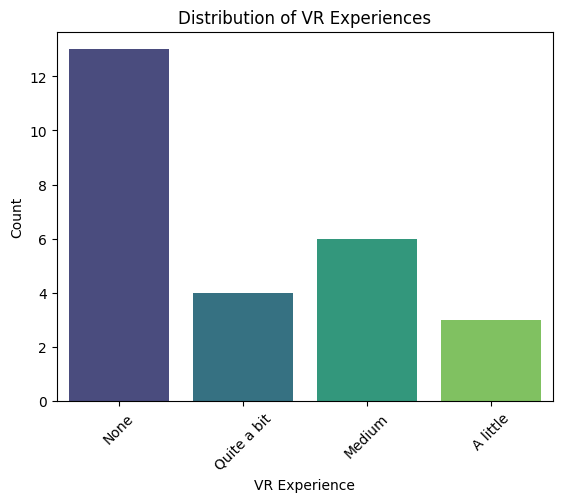

In [100]:
sns.countplot(data=df, x="Bartending", palette="viridis")
plt.title("Distribution of VR Experiences")
plt.xlabel("VR Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Post-Questionaire Data Processing

In [6]:
post_path = glob.glob("Qustionare_data\\Post\\*.xlsx")[0]
print(post_path)
df_post = pd.read_excel(post_path, sheet_name=0)
df_post 

Qustionare_data\Post\MED.xlsx


,ID,Starttidspunkt,Færdiggørelsestidspunkt,Mail,Navn,Senest ændret tidspunkt,Participant Number (Test conductor fills out),What group is this? (Test conductor fills out)\n,"To what extent did the game hold your attention? ( 7= A lot, 1 = Not at all )","To what extent did you feel you were focused on the game? ( 7= A lot, 1 = Not at all )",...,"How much would you say you enjoyed playing the game? ( 7= A lot, 1 = Not at all)","When it ended, were you disappointed that the game was over? ( 7= Very much so, 1 = Not at all)","Would you like to play the game again? ( 7 = Definitely yes, 1 = Definitely no)",How immersed did you feel?,"How mentally demanding was the task? (1 being ""Very low"" and 20 being ""Very high"")","How physically demanding was the task? (1 being ""Very low"" and 20 being ""Very high"")","How hurried or rushed was the pace of the task? (1 being ""Very low"" and 20 being ""Very high"")","How successful were you in accomplishing what you were asked to do? (1 being ""Very low"" and 20 being ""Very high"")","How hard did you have to work to accomplish your level of performance? (1 being ""Very low"" and 20 being ""Very high"")","How insecure, discouraged, irritated, stressed, and annoyed were you? (1 being ""Very low"" and 20 being ""Very high"")"
0,6,2025-05-05 10:03:43,2025-05-05 11:54:50,anonymous,NaN,NaN,1,Group C,6,7,...,6,5,7,7,10,3,6,13,13,8
1,7,2025-05-05 13:17:55,2025-05-05 13:35:54,anonymous,NaN,NaN,2,Group C,5,7,...,4,5,3,6,14,6,5,4,16,9
2,8,2025-05-05 14:01:48,2025-05-05 14:25:06,anonymous,NaN,NaN,3,Group B,5,7,...,4,7,7,10,14,6,1,1,21,5
3,9,2025-05-05 14:35:10,2025-05-05 14:55:15,anonymous,NaN,NaN,4,Group C,6,7,...,6,5,6,7,6,5,3,19,12,1
4,10,2025-05-05 15:16:02,2025-05-05 15:19:07,anonymous,NaN,NaN,5,Group C,7,5,...,6,7,7,9,17,19,18,2,18,11
5,11,2025-05-06 09:06:46,2025-05-06 09:57:10,anonymous,NaN,NaN,6,Group B,7,7,...,7,5,7,8,6,7,5,18,8,6
6,12,2025-05-06 10:25:40,2025-05-06 10:25:47,anonymous,NaN,NaN,7,Group A,7,7,...,7,6,7,7,13,7,15,3,17,10
7,13,2025-05-06 10:25:51,2025-05-06 10:56:46,anonymous,NaN,NaN,8,Group C,7,7,...,7,7,7,9,10,1,8,7,6,1
8,14,2025-05-06 10:56:52,2025-05-06 11:22:07,anonymous,NaN,NaN,9,Group B,6,7,...,6,7,6,8,5,2,1,3,4,14
9,15,2025-05-06 12:57:58,2025-05-06 12:58:03,anonymous,NaN,NaN,10,Group B,6,6,...,6,6,7,7,6,4,3,4,4,4


## Nasa-tlx

In [7]:
last_6_columns = df_post.iloc[:, -6:].copy()
last_6_columns.columns = [
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Performance",
    "Effort",
    "Frustration Level"
]

last_6_columns = last_6_columns.applymap(lambda x: min(x, 20) if pd.notna(x) else x)
TLX_allScore = last_6_columns.applymap(lambda x: x * 5 if pd.notna(x) else x)

TLX_allScore["Participant Number"] = df_post.iloc[:, 6]
TLX_allScore["Group"] = df_post.iloc[:, 7]
TLX_allScore["TLX Score"] = TLX_allScore[[
    "Mental Demand", "Physical Demand", "Temporal Demand",
    "Performance", "Effort", "Frustration Level"
]].mean(axis=1)

omega_value = calculate_omega(TLX_allScore[[
    "Mental Demand", "Physical Demand", "Temporal Demand",
    "Performance", "Effort", "Frustration Level"
]])

print(f"The reliability of the Nasa-TLX was {interpret_omega(omega_value)}, with a McDonald's Omega (TLX combined) = {omega_value:.3f}")

TLX_allScore


The reliability of the Nasa-TLX was Acceptable, with a McDonald's Omega (TLX combined) = 0.619


,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level,Participant Number,Group,TLX Score
0,50,15,30,65,65,40,1,Group C,44.166667
1,70,30,25,20,80,45,2,Group C,45.000000
2,70,30,5,5,100,25,3,Group B,39.166667
3,30,25,15,95,60,5,4,Group C,38.333333
4,85,95,90,10,90,55,5,Group C,70.833333
5,30,35,25,90,40,30,6,Group B,41.666667
6,65,35,75,15,85,50,7,Group A,54.166667
7,50,5,40,35,30,5,8,Group C,27.500000
8,25,10,5,15,20,70,9,Group B,24.166667
9,30,20,15,20,20,20,10,Group B,20.833333


In [8]:
TLX_allScore.describe()

,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level,Participant Number,TLX Score
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,53.076923,38.846154,36.153846,51.346154,57.692308,29.615385,13.500000,44.455128
std,20.448810,25.310381,22.552503,27.624543,21.504919,19.438265,7.648529,11.841411
min,20.000000,5.000000,5.000000,5.000000,20.000000,5.000000,1.000000,20.833333
25%,35.000000,20.000000,25.000000,27.500000,42.500000,15.000000,7.250000,38.541667
50%,55.000000,32.500000,27.500000,57.500000,60.000000,27.500000,13.500000,44.166667
75%,70.000000,50.000000,47.500000,70.000000,73.750000,43.750000,19.750000,48.333333
max,85.000000,95.000000,90.000000,95.000000,100.000000,70.000000,26.000000,70.833333


In [9]:
testing_for_assumptions_by_group(TLX_allScore, score_col="TLX Score", group_col="Group")

# Testing assumptions for TLX Score #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9270, p = 0.4534 → Data appears normal

Group Group B:
  ✔️ Stat = 0.8591, p = 0.0937 → Data appears normal

Group Group A:
  ✔️ Stat = 0.8748, p = 0.1677 → Data appears normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 1.9484, p = 0.1653 → Variances are equal

# Final Group Comparison Test for TLX Score #
✅ All assumptions met. Running ANOVA:
  ✔️ ANOVA Stat = 1.3941, p = 0.2682


In [10]:
testing_for_assumptions_by_group(TLX_allScore,score_col="Performance")

# Testing assumptions for Performance #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9342, p = 0.5226 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9614, p = 0.8129 → Data appears normal

Group Group A:
  ❌ Stat = 0.7599, p = 0.0105 → Data not normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.3879, p = 0.6828 → Variances are equal

# Final Group Comparison Test for Performance #
❌ Assumptions not met. Using non-parametric Kruskal–Wallis:
  ✔️ Kruskal–Wallis Stat = 1.9927, p = 0.3692


In [48]:
group_a_tlx = TLX_allScore[TLX_allScore["Group"] == "Group A"]["TLX Score"]
group_b_tlx = TLX_allScore[TLX_allScore["Group"] == "Group B"]["TLX Score"]
group_c_tlx = TLX_allScore[TLX_allScore["Group"] == "Group C"]["TLX Score"]

SS stands for Sum of Squares
SS_between: 379.0190
SS_within: 3126.4564
SS_total: 3505.4754
Effect Size (Eta Squared, η²): 0.1081
ANOVA Results: F-statistic = 1.3941, p-value = 0.2682
No significant difference between the groups.


C:\Users\Christian\AppData\Local\Temp\ipykernel_17060\3431445066.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(data, labels=["Group A", "Group B", "Group C"], patch_artist=True, showmeans=True)


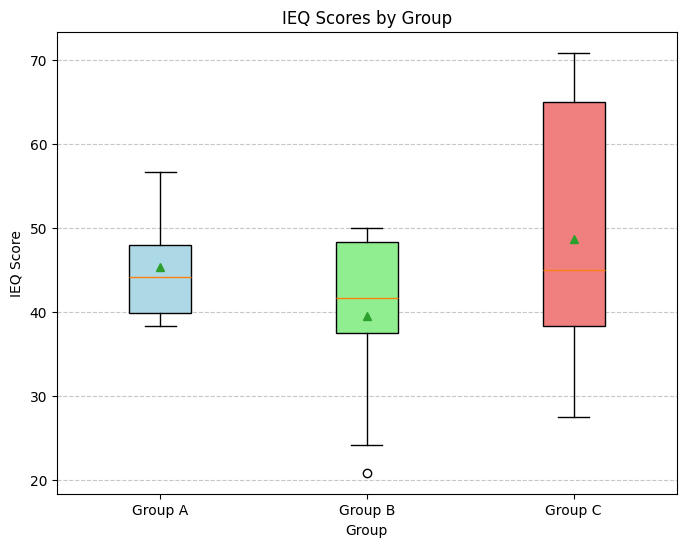

In [49]:
# Combine all groups into one dataset
all_data = pd.concat([group_a_tlx, group_b_tlx, group_c_tlx])
grand_mean = all_data.mean()

# Calculate Sum of Squares Between (SS_between)
n_a, n_b, n_c = len(group_a_tlx), len(group_b_tlx), len(group_c_tlx)
mean_a_tlx, mean_b_tlx, mean_c_tlx = group_a_tlx.mean(), group_b_tlx.mean(), group_c_tlx.mean()
SS_between_tlx = n_a * (mean_a_tlx - grand_mean)**2 + n_b * (mean_b_tlx - grand_mean)**2 + n_c * (mean_c_tlx - grand_mean)**2

# Calculate Sum of Squares Within (SS_within)
SS_within_tlx = sum((group_a_tlx - mean_a_tlx)**2) + sum((group_b_tlx - mean_b_tlx)**2) + sum((group_c_tlx - mean_c_tlx)**2)

# Calculate Total Sum of Squares (SS_total)
SS_total_tlx = SS_between_tlx + SS_within_tlx

# Calculate Eta Squared (η²)
eta_squared_tlx = SS_between_tlx / SS_total_tlx

# Print results
print("SS stands for Sum of Squares")
print(f"SS_between: {SS_between_tlx:.4f}")
print(f"SS_within: {SS_within_tlx:.4f}")
print(f"SS_total: {SS_total_tlx:.4f}")
print(f"Effect Size (Eta Squared, η²): {eta_squared_tlx:.4f}")

# Perform one-way ANOVA
stat, p = f_oneway(group_a_tlx, group_b_tlx, group_c_tlx)
print(f"ANOVA Results: F-statistic = {stat:.4f}, p-value = {p:.4f}")
if p < 0.05:
    print("There is a significant difference between the groups.")
else:
    print("No significant difference between the groups.")

# Plot the scores for each group
plt.figure(figsize=(8, 6))
data = [group_a_tlx, group_b_tlx, group_c_tlx]
boxplot = plt.boxplot(data, labels=["Group A", "Group B", "Group C"], patch_artist=True, showmeans=True)
plt.title("IEQ Scores by Group")

# Assign different colors to each group
colors = ['lightblue', 'lightgreen', 'lightcoral']
for box, color in zip(boxplot['boxes'], colors):
    box.set_facecolor(color)

plt.ylabel("IEQ Score")
plt.xlabel("Group")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [54]:
# Columns to test
columns_to_test = ["Mental Demand", "Physical Demand", "Temporal Demand", "Performance", "Effort", "Frustration Level"]

# Initialize a list to store the results
results = []

for col in columns_to_test:
    print(f"\n### Testing for {col} ###")
    
    # Extract data for each group
    group_a = TLX_allScore[TLX_allScore["Group"] == "Group A"][col]
    group_b = TLX_allScore[TLX_allScore["Group"] == "Group B"][col]
    group_c = TLX_allScore[TLX_allScore["Group"] == "Group C"][col]
    
    # Check assumptions and decide the test
    test_type = testing_for_assumptions_by_group(TLX_allScore, score_col=col, group_col="Group")
    
    if test_type == 1:  # ANOVA
        print(f"Running ANOVA for {col}")
        stat, p = f_oneway(group_a, group_b, group_c)
        test_name = "ANOVA"
    elif test_type == 0:  # Kruskal-Wallis
        print(f"Running Kruskal-Wallis for {col}")
        stat, p = kruskal(group_a, group_b, group_c)
        test_name = "Kruskal-Wallis"
    else:
        print(f"Not enough data to test {col}.")
        results.append({"Column": col, "Test": "Not enough data", "p-value": None, "Significant": "No"})
        continue  # Skip to the next column if there's not enough data
    
    # Determine significance
    significant = "Yes" if p < 0.05 else "No"
    
    # Append the result to the list
    results.append({"Column": col, "Test": test_name, "p-value": p, "Significant": significant})
    
    # If p-value is less than 0.05, create a plot
    if p < 0.05:
        print(f"Significant result for {col} (p = {p:.4f}). Creating a plot...")
        
        # Combine data for plotting
        data = [group_a, group_b, group_c]
        labels = ["Group A", "Group B", "Group C"]
        
        # Create a boxplot
        plt.figure(figsize=(8, 6))
        boxplot = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=True)
        
        # Assign colors to each group
        colors = ['lightblue', 'lightgreen', 'lightcoral']
        for patch, color in zip(boxplot['boxes'], colors):
            patch.set_facecolor(color)
        
        # Add plot title and labels
        plt.title(f"{col} by Group")
        plt.ylabel(col)
        plt.xlabel("Group")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Show the plot
        plt.show()

# Create a summary DataFrame
summary_df = pd.DataFrame(results)

# Display the summary DataFrame
print("\n### Summary of Findings ###")
print(summary_df)


### Testing for Mental Demand ###
# Testing assumptions for Mental Demand #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.8782, p = 0.1502 → Data appears normal

Group Group B:
  ✔️ Stat = 0.8780, p = 0.1495 → Data appears normal

Group Group A:
  ✔️ Stat = 0.9540, p = 0.7512 → Data appears normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.0904, p = 0.9139 → Variances are equal

# Final Group Comparison Test for Mental Demand #
✅ All assumptions met. Running ANOVA:
  ✔️ ANOVA Stat = 1.7074, p = 0.2035
Running ANOVA for Mental Demand

### Testing for Physical Demand ###
# Testing assumptions for Physical Demand #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9144, p = 0.3480 → Data appears normal

Group Group B:
  ✔️ Stat = 0.8991, p = 0.2471 → Data appears normal

Group Group A:
  ✔️ Stat = 0.8845, p = 0.2077 → Data appears normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.5067, p = 0.6090 → Variances are equal

# Fin

## IEQ

In [11]:
questions_df = df_post.iloc[:, 8:39].copy()
questions_df = questions_df.apply(pd.to_numeric, errors='coerce')

questions_to_reverse_indices = [5, 7, 9, 17, 19]
for index in questions_to_reverse_indices:
    column_name = questions_df.columns[index]
    questions_df[column_name] = 8 - questions_df[column_name]

IEQ_scores_list = questions_df.sum(axis=1, skipna=True)
IEQ_scores = pd.DataFrame({
    "IEQ Score": IEQ_scores_list,
    "Participant Number": df_post.iloc[:, 6].values,
    "Group": df_post.iloc[:, 7].values,
    "Single Question Measure of Immersion": df_post.iloc[:, 39].values
})

omega_ieq = calculate_omega(questions_df)
print(f"The reliability of the IEQ was {interpret_omega(omega_ieq)}, with a McDonald's Omega (TLX combined) = {omega_ieq:.3f}")
IEQ_scores

The reliability of the IEQ was Good, with a McDonald's Omega (TLX combined) = 0.777


,IEQ Score,Participant Number,Group,Single Question Measure of Immersion
0,173,1,Group C,7
1,137,2,Group C,6
2,161,3,Group B,10
3,163,4,Group C,7
4,172,5,Group C,9
5,161,6,Group B,8
6,171,7,Group A,7
7,159,8,Group C,9
8,166,9,Group B,8
9,167,10,Group B,7


In [12]:
IEQ_scores.describe()

,IEQ Score,Participant Number,Single Question Measure of Immersion
count,26.000000,26.000000,26.000000
mean,162.500000,13.500000,7.538462
std,13.234047,7.648529,1.207668
min,137.000000,1.000000,5.000000
25%,157.000000,7.250000,7.000000
50%,162.000000,13.500000,7.000000
75%,172.750000,19.750000,8.000000
max,184.000000,26.000000,10.000000


In [13]:
testing_for_assumptions_by_group(IEQ_scores, score_col="IEQ Score", group_col="Group")

# Testing assumptions for IEQ Score #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9141, p = 0.3459 → Data appears normal

Group Group B:
  ✔️ Stat = 0.8936, p = 0.2171 → Data appears normal

Group Group A:
  ✔️ Stat = 0.9139, p = 0.3822 → Data appears normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.0980, p = 0.9070 → Variances are equal

# Final Group Comparison Test for IEQ Score #
✅ All assumptions met. Running ANOVA:
  ✔️ ANOVA Stat = 0.6658, p = 0.5235


In [14]:
testing_for_assumptions_by_group(IEQ_scores, score_col="Single Question Measure of Immersion", group_col="Group")

# Testing assumptions for Single Question Measure of Immersion #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.8838, p = 0.1719 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9498, p = 0.6874 → Data appears normal

Group Group A:
  ❌ Stat = 0.6756, p = 0.0012 → Data not normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.6522, p = 0.5303 → Variances are equal

# Final Group Comparison Test for Single Question Measure of Immersion #
❌ Assumptions not met. Using non-parametric Kruskal–Wallis:
  ✔️ Kruskal–Wallis Stat = 0.9939, p = 0.6084


In [ ]:
# Extract data for each group
group_a_ieq = IEQ_scores[IEQ_scores["Group"] == "Group A"]["IEQ Score"]
group_b_ieq = IEQ_scores[IEQ_scores["Group"] == "Group B"]["IEQ Score"]
group_c_ieq = IEQ_scores[IEQ_scores["Group"] == "Group C"]["IEQ Score"]

print("#Low fi group: ")
print(group_a_ieq.describe())

#Low fi group: 
count      8.000000
mean     160.500000
std       13.835771
min      144.000000
25%      152.250000
50%      157.000000
75%      172.000000
max      181.000000
Name: IEQ Score, dtype: float64


In [ ]:
print("#Low mid group: ")
print(group_b_ieq.describe())

#Low mid group: 
count      9.000000
mean     160.111111
std       12.313046
min      137.000000
25%      159.000000
50%      161.000000
75%      167.000000
max      174.000000
Name: IEQ Score, dtype: float64


In [ ]:
print("#Low hi group: ")
print(group_c_ieq.describe())

#Low hi group: 
count      9.000000
mean     166.666667
std       14.080128
min      137.000000
25%      159.000000
50%      172.000000
75%      174.000000
max      184.000000
Name: IEQ Score, dtype: float64


SS stands for Sum of Squares
SS_between: 239.6111
SS_within: 4138.8889
SS_total: 4378.5000
Effect Size (Eta Squared, η²): 0.0547
ANOVA Results: F-statistic = 0.6658, p-value = 0.5235
No significant difference between the groups.


C:\Users\Christian\AppData\Local\Temp\ipykernel_17060\1182566836.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)


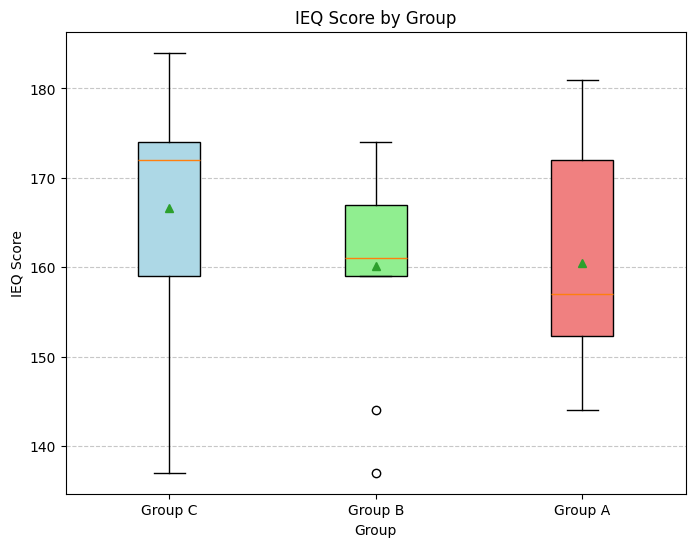

{'SS_between': 239.61111111111026, 'SS_within': 4138.888888888889, 'SS_total': 4378.499999999999, 'eta_squared': 0.05472447438874279, 'anova_stat': 0.665765100671141, 'anova_p_value': 0.5235061119125362}


In [77]:
results_IEQ = analyze_groups_anova(df=IEQ_scores, score_col="IEQ Score", group_col="Group")
print(results_IEQ)

In [39]:
print("Welch's ANOVA Results")
pg.welch_anova(dv='IEQ Score', between='Group', data=IEQ_scores) 

Welch's ANOVA Results


,Source,ddof1,ddof2,F,p-unc,np2
0,Group,2,15.083462,0.615361,0.553472,0.054724


In [ ]:
# Group A vs Group C
stat_ac, p_ac = ttest_ind(group_c_ieq, group_b_ieq, equal_var=True)  # Use equal_var=True if variances are equal
print(f"Group A vs Group C: t-statistic = {stat_ac:.4f}, one-tailed p-value = {p_ac:.4f}")
# Group A vs Group B
stat_bc, p_bc = ttest_ind(group_c_ieq, group_b_ieq, equal_var=True)
print(f"Group B vs Group C: t-statistic = {stat_bc:.4f}, one-tailed p-value = {p_bc:.4f}")

Group A vs Group C: t-statistic = 1.0514, one-tailed p-value = 0.3087
Group B vs Group C: t-statistic = 1.0514, one-tailed p-value = 0.3087


Kruskal-Wallis test statistic = 0.9939, p-value = 0.6084
No significant difference between the groups.


C:\Users\Christian\AppData\Local\Temp\ipykernel_17060\23711797.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)


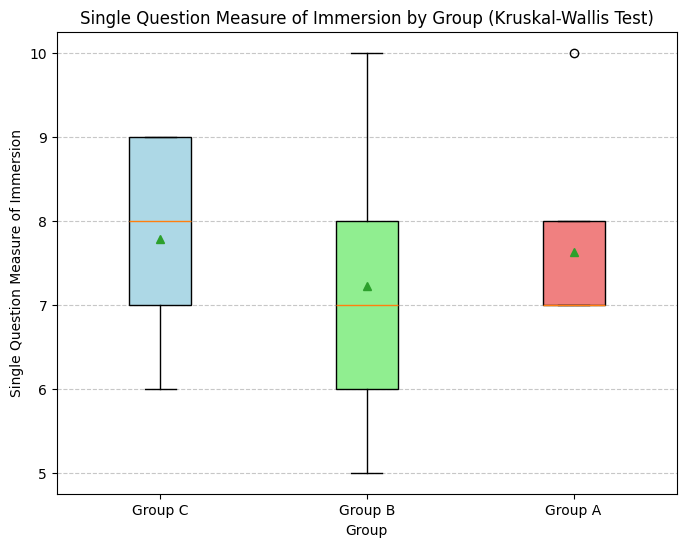

{'kruskal_stat': 0.9938672438672433, 'kruskal_p_value': 0.6083933664461629}


In [79]:
results = analyze_kruskal_test(df=IEQ_scores, score_col="Single Question Measure of Immersion", group_col="Group")
print(results)

In [66]:
threshold = 31 
singleQuestionScalingFactor = 21.7 # (217 - 31)/10

# Calculate the absolute difference between the Single Question score and the IEQ Score
IEQ_scores["Difference"] = abs(IEQ_scores["Single Question Measure of Immersion"] * 21.7 - IEQ_scores["IEQ Score"])

# Identify rows where the difference exceeds the threshold
outliers_df = IEQ_scores[IEQ_scores["Difference"] > threshold]

# Print the outliers
print("Outliers based on the difference between Single Question and IEQ Score:")
print(outliers_df)

# Optionally, drop the outliers from the original DataFrame
filtered_df = IEQ_scores[IEQ_scores["Difference"] <= threshold]
print(filtered_df.describe())
filtered_df

Outliers based on the difference between Single Question and IEQ Score:
    IEQ Score  Participant Number    Group  \
2         161                   3  Group B   
7         159                   8  Group C   
10        181                  11  Group A   

    Single Question Measure of Immersion  Difference  
2                                     10        56.0  
7                                      9        36.3  
10                                    10        36.0  
        IEQ Score  Participant Number  Single Question Measure of Immersion  \
count   23.000000           23.000000                             23.000000   
mean   161.913043           14.304348                              7.260870   
std     13.507281            7.689632                              0.963771   
min    137.000000            1.000000                              5.000000   
25%    156.000000            8.000000                              7.000000   
50%    163.000000           15.000000            

,IEQ Score,Participant Number,Group,Single Question Measure of Immersion,Difference
0,173,1,Group C,7,21.1
1,137,2,Group C,6,6.8
3,163,4,Group C,7,11.1
4,172,5,Group C,9,23.3
5,161,6,Group B,8,12.6
6,171,7,Group A,7,19.1
8,166,9,Group B,8,7.6
9,167,10,Group B,7,15.1
11,144,12,Group B,6,13.8
12,144,13,Group A,7,7.9


In [69]:
testing_for_assumptions_by_group(filtered_df, score_col="IEQ Score", group_col="Group")

# Testing assumptions for IEQ Score #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.8884, p = 0.2263 → Data appears normal

Group Group B:
  ✔️ Stat = 0.8945, p = 0.2578 → Data appears normal

Group Group A:
  ✔️ Stat = 0.8977, p = 0.3171 → Data appears normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.0414, p = 0.9595 → Variances are equal

# Final Group Comparison Test for IEQ Score #
✅ All assumptions met. Running ANOVA:
  ✔️ ANOVA Stat = 1.1756, p = 0.3291


1

In [68]:
testing_for_assumptions_by_group(filtered_df, score_col="Single Question Measure of Immersion", group_col="Group")

# Testing assumptions for Single Question Measure of Immersion #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9116, p = 0.3657 → Data appears normal

Group Group B:
  ✔️ Stat = 0.8821, p = 0.1973 → Data appears normal

Group Group A:
  ❌ Stat = 0.6004, p = 0.0003 → Data not normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 2.7369, p = 0.0890 → Variances are equal

# Final Group Comparison Test for Single Question Measure of Immersion #
❌ Assumptions not met. Using non-parametric Kruskal–Wallis:
  ✔️ Kruskal–Wallis Stat = 1.6168, p = 0.4456


0

SS stands for Sum of Squares
SS_between: 422.2368
SS_within: 3591.5893
SS_total: 4013.8261
Effect Size (Eta Squared, η²): 0.1052
ANOVA Results: F-statistic = 1.1756, p-value = 0.3291
No significant difference between the groups.


C:\Users\Christian\AppData\Local\Temp\ipykernel_17060\1182566836.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)


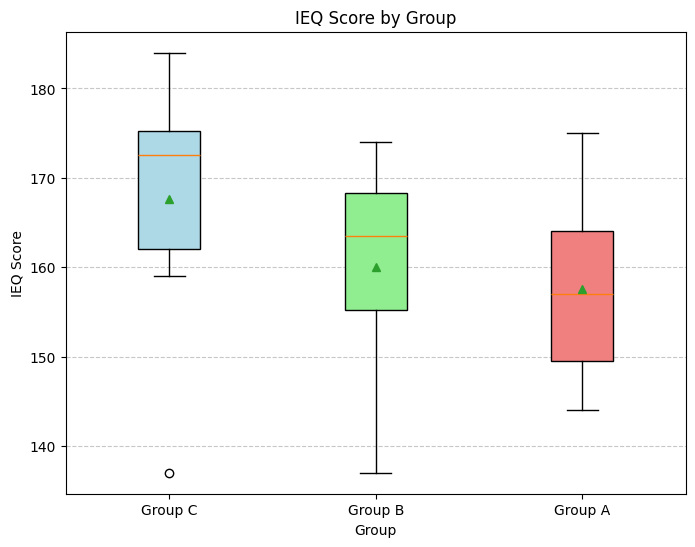

{'SS_between': 422.2368012422353, 'SS_within': 3591.589285714286, 'SS_total': 4013.826086956521, 'eta_squared': 0.10519558946869964, 'anova_stat': 1.1756266311454444, 'anova_p_value': 0.32906459730783477}


In [76]:
results_filterd_IEQ = analyze_groups_anova(df=filtered_df, score_col="IEQ Score", group_col="Group")
print(results_filterd_IEQ)

Kruskal-Wallis test statistic = 1.6168, p-value = 0.4456
No significant difference between the groups.


C:\Users\Christian\AppData\Local\Temp\ipykernel_17060\23711797.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(group_data, labels=groups, patch_artist=True, showmeans=True)


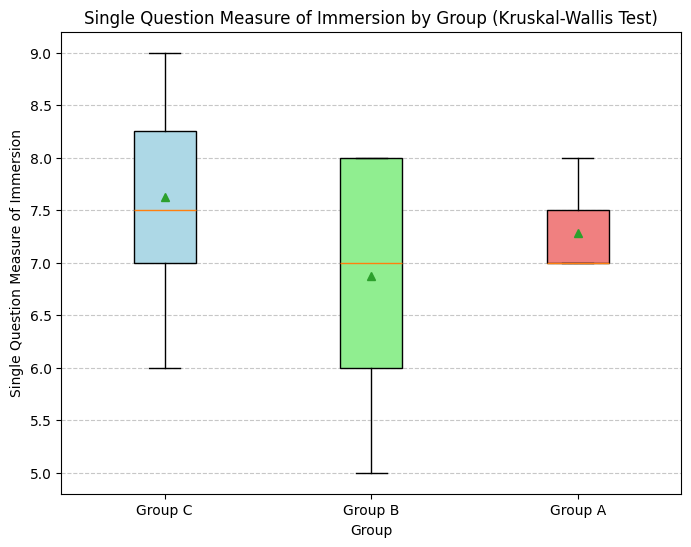

{'kruskal_stat': 1.6167666454790932, 'kruskal_p_value': 0.4455778398067566}


In [80]:
results = analyze_kruskal_test(df=filtered_df, score_col="Single Question Measure of Immersion", group_col="Group")
print(results)

In [85]:
# Merge the two DataFrames on the "Participant Number" column
merged_df = pd.merge(TLX_allScore, IEQ_scores, on="Participant Number", suffixes=("_TLX", "_IEQ"))
merged_df

,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level,Participant Number,Group_TLX,TLX Score,IEQ Score,Group_IEQ,Single Question Measure of Immersion,Difference
0,50,15,30,65,65,40,1,Group C,44.166667,173,Group C,7,21.1
1,70,30,25,20,80,45,2,Group C,45.000000,137,Group C,6,6.8
2,70,30,5,5,100,25,3,Group B,39.166667,161,Group B,10,56.0
3,30,25,15,95,60,5,4,Group C,38.333333,163,Group C,7,11.1
4,85,95,90,10,90,55,5,Group C,70.833333,172,Group C,9,23.3
5,30,35,25,90,40,30,6,Group B,41.666667,161,Group B,8,12.6
6,65,35,75,15,85,50,7,Group A,54.166667,171,Group A,7,19.1
7,50,5,40,35,30,5,8,Group C,27.500000,159,Group C,9,36.3
8,25,10,5,15,20,70,9,Group B,24.166667,166,Group B,8,7.6
9,30,20,15,20,20,20,10,Group B,20.833333,167,Group B,7,15.1


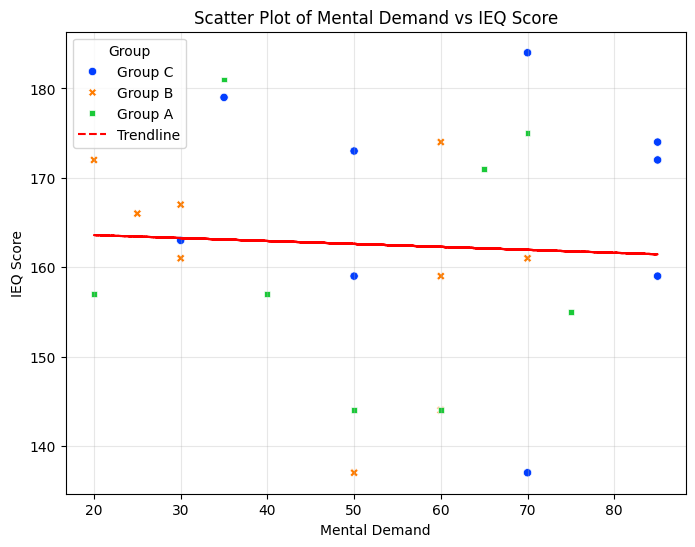

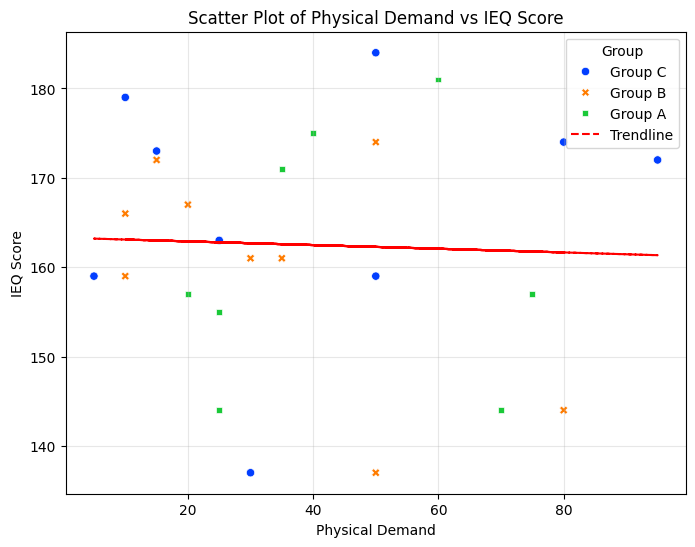

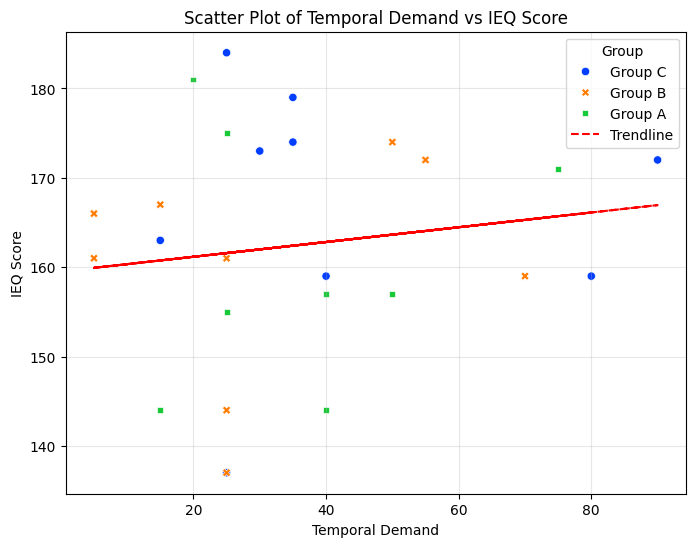

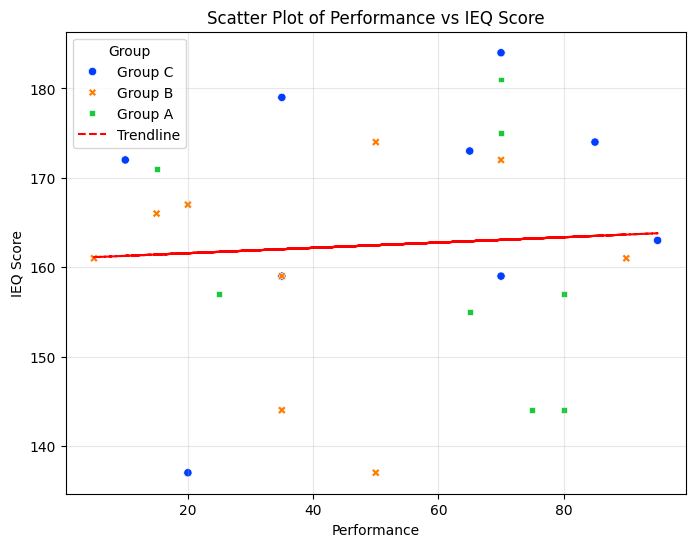

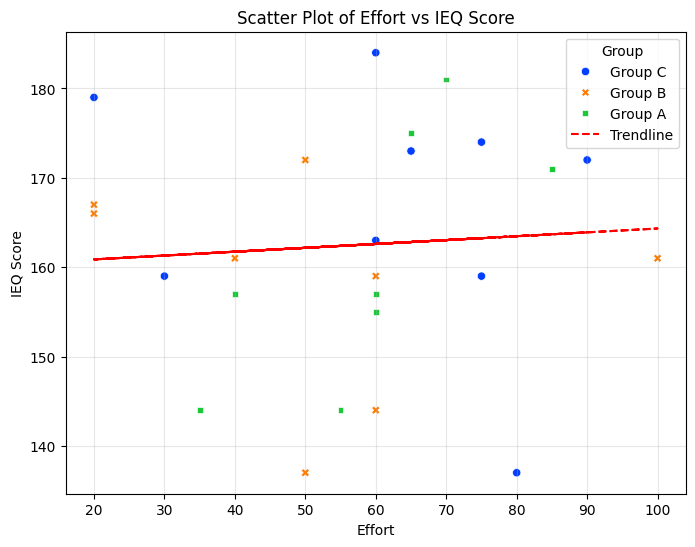

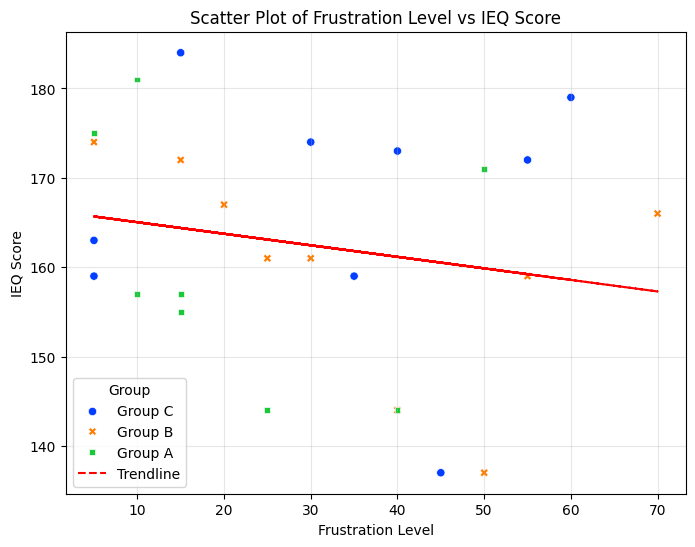

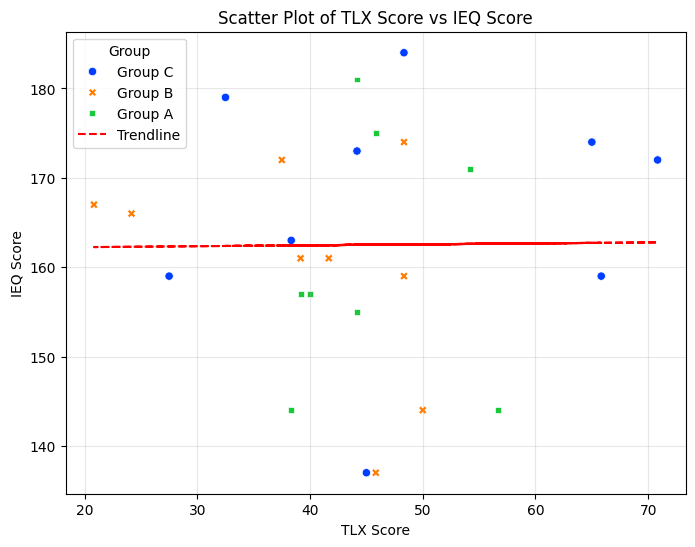

In [89]:
# List of columns to compare with IEQ Score
columns_to_compare = ["Mental Demand", "Physical Demand", "Temporal Demand", "Performance", "Effort", "Frustration Level", "TLX Score"]

# Loop through each column and create a scatter plot
for col in columns_to_compare:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=merged_df[col],
        y=merged_df["IEQ Score"],
        hue=merged_df["Group_IEQ"],
        palette="bright",
        style=merged_df["Group_IEQ"]
    )
    
    # Add a trendline
    z = np.polyfit(merged_df[col], merged_df["IEQ Score"], 1)
    p = np.poly1d(z)
    plt.plot(merged_df[col], p(merged_df[col]), color="red", linestyle="--", label="Trendline")
    
    # Add labels, title, and legend
    plt.xlabel(col)
    plt.ylabel("IEQ Score")
    plt.title(f"Scatter Plot of {col} vs IEQ Score")
    plt.legend(title="Group")
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
# Merge the VR experience data with the group information
vr_experience_df = pd.DataFrame({
    "Participant Number": questions_df.index + 1,
    "VR Exp erience": df["VR"],
    "Group": questions_df["What group is this? (Test conductor fills out)"]
})

# Create a count plot
plt.figure(figsize=(10, 6))
sns.countplot(data=vr_experience_df, x="Group", hue="VR Experience", palette="viridis")
plt.title("VR Experiences Across Different Groups")
plt.xlabel("Group")
plt.ylabel("Count")
plt.legend(title="VR Experience")
plt.show()

KeyError: 'What group is this? (Test conductor fills out)'